# OpenAI Chat Completions API 기본 (2025년 3월 기준)

이 튜토리얼은 OpenAI의 Chat Completions API를 활용하여 챗봇이나 AI 기능을 개발하는 방법을 단계별로 설명합니다. 특히 OpenAI의 최신 언어 모델 중 하나인 GPT-4o를 사용하여 예제를 진행할 것입니다. 각 섹션에는 개념 설명과 함께 실행 가능한 파이썬 코드 예제가 포함되어 있습니다.

### 주요 학습 내용:

1. OpenAI API 소개 및 환경 설정: OpenAI API 개요, API 키 발급 및 보안 설정, 파이썬 클라이언트 설치 및 인스턴스 생성 방법
2. 기본적인 Chat Completions API 사용법: 간단한 대화형 텍스트 생성 요청과 응답 처리, 프롬프트 엔지니어링 기초
3. 스트리밍 응답: 대화 응답을 스트리밍 방식으로 받아 실시간 처리하는 방법
4. 시스템 메시지 활용: 시스템 역할 메시지를 사용하여 AI의 응답 스타일이나 행동을 조정하는 방법
5. 고급 활용법: 토큰 최적화와 비용 절감 전략, OpenAI API 에러 처리 및 예외Handling
6. 실전 프로젝트 예제: 간단한 챗봇 구현 및 외부 데이터/API와 연동하여 데이터 분석 기능을 결합한 사례

## 1. OpenAI API 소개 및 환경 설정

먼저 OpenAI API와 Chat Completions에 대해 간략히 알아보고, API를 사용하기 위한 환경을 설정해보겠습니다.

### OpenAI API 개요
OpenAI API는 GPT 계열의 대규모 언어 모델을 인터넷을 통해 사용할 수 있도록 제공하는 서비스입니다. Chat Completions API는 챗봇과 유사한 대화형 상호작용을 할 수 있는 엔드포인트로, 역할(role)이 부여된 메시지 목록을 입력하면 모델이 다음 대화 내용을 생성합니다. GPT-4o는 2025년 3월 현재 가장 강력한 모델 중 하나로, 텍스트와 이미지 입력을 모두 처리하며 최대 128k 토큰의 긴 문맥을 다룰 수 있습니다. GPT-4o와 경량화 모델인 GPT-4o-mini 등이 제공되며, 요구 사항에 따라 적절한 모델을 선택할 수 있습니다 (GPT-4o-mini는 비용 효율이 높음)

### API 키 발급 및 보안 설정
OpenAI API를 사용하려면 먼저 OpenAI 계정에서 API 키를 발급받아야 합니다. OpenAI 웹사이트의 API Keys 페이지에서 새로운 비밀 키를 생성할 수 있습니다. 발급받은 API 키는 비밀로 관리해야 하며, 소스 코드나 공개 저장소에 노출되지 않도록 주의해야 합니다. 가장 좋은 방법은 API 키를 코드에 하드코딩하지 않고, 환경 변수나 별도의 설정 파일에 저장하는 것입니다. 이 튜토리얼에서는 .env 파일에 키를 저장하고 파이썬에서 이를 불러오는 방식을 사용합니다. 이를 위해 Python용 패키지 **python-dotenv**를 활용하겠습니다.

- .env 파일에 키 저장: 프로젝트 디렉터리에 .env 파일을 만들고 아래와 같이 API 키를 저장합니다 (따옴표 없이).

    ```
    OPENAI_API_KEY=발급받은-API키-값
    ```

- python-dotenv 사용: 파이썬 코드에서 python-dotenv를 이용해 .env 파일의 환경 변수를 불러올 수 있습니다.


In [1]:
import openai
openai.__version__

'1.91.0'

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()
# openai_api_key = os.getenv('OpenAi_API_KEY')

True

In [3]:
from openai import OpenAI
client = OpenAI(
    # api_key=_key=~
)

위 코드로 client 객체가 생성되었습니다. 이제 이 client를 통해 OpenAI Chat Completions API를 호출할 수 있습니다. 다음 섹션부터는 실제로 Chat Completions API를 호출하여 다양한 기능을 실습해보겠습니다.

## 2. 기본적인 Chat Completions API 사용법

이 섹션에서는 Chat Completions API를 사용하여 가장 기본적인 대화 생성 작업을 수행해봅니다.

### 간단한 텍스트 생성 요청
Chat Completions 엔드포인트는 메시지 목록을 입력으로 받아 다음에 이어질 메시지를 생성합니다. 각 메시지는 role과 content 필드로 구성되어 있으며, 일반적으로 **user (사용자 메시지), assistant (모델의 응답 메시지), system (시스템 지시 메시지)** 세 가지 역할을 사용합니다. 가장 간단한 예제로, 사용자 역할의 메시지 하나를 모델에 보내고 응답을 받아보겠습니다. 모델은 gpt-4.1-nano를 사용합니다.


In [4]:
# 사용자 메세지 구성
messages = [
    {"role":"user", "content":"오늘 날씨를 말해주세요"}
]
response = client.chat.completions.create(
    model="gpt-4.1-nano",
    messages=messages,
    temperature=0.7, # 0~2 : 일관적~창의적(예측을 벗어난)
    frequency_penalty=0.5
)
response

ChatCompletion(id='chatcmpl-Bmc6Lyw6R3G5wFceM6tNyQb7NB9Oe', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='죄송하지만, 저는 실시간 정보를 제공할 수 없기 때문에 오늘의 날씨를 알려드릴 수 없습니다. 최신 날씨 정보를 확인하시려면 기상청 홈페이지나 날씨 앱을 참고하시기 바랍니다.', refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=None))], created=1750925905, model='gpt-4.1-nano-2025-04-14', object='chat.completion', service_tier='default', system_fingerprint='fp_38343a2f8f', usage=CompletionUsage(completion_tokens=47, prompt_tokens=13, total_tokens=60, completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=0, audio_tokens=0, reasoning_tokens=0, rejected_prediction_tokens=0), prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cached_tokens=0)))

In [5]:
response.choices[0].message.content

'죄송하지만, 저는 실시간 정보를 제공할 수 없기 때문에 오늘의 날씨를 알려드릴 수 없습니다. 최신 날씨 정보를 확인하시려면 기상청 홈페이지나 날씨 앱을 참고하시기 바랍니다.'

In [6]:
response = client.chat.completions.create(
    model="gpt-4.1-nano",
    messages=[
        {"role":"system", "content":"너는 친절하게 대답해 주는 전문가야."},
        {"role":"user", "content":"2020년 월드 시리즈에서 누가 우승했어?"},
    ],
    temperature=1,
    frequency_penalty=0.5
)
print(response.choices[0].message.content)

2020년 월드 시리즈에서 로스앤젤레스 다저스가 우승했어요. 다저스는 텍사스 레인저스를 4승 3패로 이기고 챔피언 자리를 차지했답니다.


In [7]:
# 이전 답변을 포함하여 답변하기
response = client.chat.completions.create(
    model="gpt-4.1-nano",
    messages=[
        {"role":"system", "content":"너는 친절하게 답변해 주는 비서야."}, # 역할 부여
        {"role":"user", "content":"2002년 월드컵에서 가장 화제가 되었던 나라는 어디야?"},
        {"role":"assistant", "content":"바로 예상을 뚫고 4강 진출 신화를 일으킨 한국입니다."},
        {"role":"user", "content":"화제가된 이유를 3줄로 설명해줘."},
    ],
    
)
print(response.choices[0].message.content)

2002년 월드컵에서 한국이 화제가 된 이유는 첫째, 세계 최초로 한일 공동 개최로 많은 이목을 끌었기 때문입니다. 둘째, 한국이 강호들을 차례로 돌파하며 4강에 오르는 놀라운 성적을 거두었기 때문입니다. 셋째, 열정적인 응원과 큰 감동을 주며 국내외 축구 팬들에게 깊은 인상을 남겼기 때문입니다.


In [8]:
# JSON 형태로 받기
response = client.chat.completions.create(
    model="gpt-4.1-nano",
    response_format={"type":"json_object"}, # json형태로 응답
    messages=[
        {"role":"system", "content":"너는 친절하게 답변해 주는 비서야. output은 JSON으로 해줘."}, # 역할 부여
        {"role":"user", "content":"RUST언어에 대해 설명해줘"},
    ]
)
print(response.choices[0].message.content)

{
  "RUST_언어_설명": {
    "개요": "Rust는 모질라(Mozilla)에서 개발한 시스템 프로그래밍 언어로, 안전성과 성능을 동시에 제공하는 것이 특징입니다.",
    "특징": [
      "메모리 안전성: 컴파일 타임에 데이터 경쟁과 버그를 방지하는 강력한 안전성 시스템",
      "성능: C/C++와 비슷한 수준의 빠른 실행 속도",
      "병행성: 안전한 병행 프로그래밍을 지원하는 강력한 병행성 모델",
      "패키지 관리: Cargo라는 빌드 및 패키지 관리 도구 제공",
      "풍부한 타입 시스템: 강력한 정적 타입 시스템으로 오류를 미리 방지"
    ],
    "용도": [
      "시스템 소프트웨어 개발",
      "임베디드 시스템",
      "웹 어셈블리(WASM)",
      "게임 개발",
      "서버 애플리케이션"
    ],
    "장점": [
      "높은 안전성으로 버그와 취약점 감소",
      "성능이 우수하여 컴파일된 코드 빠름",
      "모든 수준에서 병행성 지원"
    ],
    "단점": [
      "학습 곡선이 다소 가파를 수 있음",
      "생태계가 일부 다른 언어에 비해 작을 수 있음"
    ],
    "결론": "Rust는 안전성과 성능을 동시에 추구하는 현대적인 시스템 프로그래밍 언어로, 빠른 성능과 안전성이 중요한 프로젝트에 적합합니다."
  }
}


In [9]:
result = response.choices[0].message.content

In [10]:
import json
dic_result = json.loads(result)
dic_result

{'RUST_언어_설명': {'개요': 'Rust는 모질라(Mozilla)에서 개발한 시스템 프로그래밍 언어로, 안전성과 성능을 동시에 제공하는 것이 특징입니다.',
  '특징': ['메모리 안전성: 컴파일 타임에 데이터 경쟁과 버그를 방지하는 강력한 안전성 시스템',
   '성능: C/C++와 비슷한 수준의 빠른 실행 속도',
   '병행성: 안전한 병행 프로그래밍을 지원하는 강력한 병행성 모델',
   '패키지 관리: Cargo라는 빌드 및 패키지 관리 도구 제공',
   '풍부한 타입 시스템: 강력한 정적 타입 시스템으로 오류를 미리 방지'],
  '용도': ['시스템 소프트웨어 개발', '임베디드 시스템', '웹 어셈블리(WASM)', '게임 개발', '서버 애플리케이션'],
  '장점': ['높은 안전성으로 버그와 취약점 감소', '성능이 우수하여 컴파일된 코드 빠름', '모든 수준에서 병행성 지원'],
  '단점': ['학습 곡선이 다소 가파를 수 있음', '생태계가 일부 다른 언어에 비해 작을 수 있음'],
  '결론': 'Rust는 안전성과 성능을 동시에 추구하는 현대적인 시스템 프로그래밍 언어로, 빠른 성능과 안전성이 중요한 프로젝트에 적합합니다.'}}

In [15]:
## 웹 예제
def askGpt(prompt):
    "GPT에게 prompt요청 결과 반환"
    client = OpenAI()
    response = client.chat.completions.create(
        model="gpt-4.1-nano",
        messages=[
            {"role":"system", 
             "content":"당신은 한국어로 된 텍스트를 잘 요약하는 전문 어시스턴트입니다"
            },
            {"role":"user", "content":prompt}
        ]
    )
    return response.choices[0].message.content

In [16]:
message = input('요약할 글을 입력하세요')
if message:
    prompt = f"""your task is to summarize the text sentences in Korean language.
    Summarize in 3 lines. use the format of a bullet point.
    text : {message}"""
    result = askGpt(prompt)
    print(result)

- 짱구는 인기 있는 만화 및 애니메이션 캐릭터입니다.  
- 그의 유쾌한 성격과 개성 있는 행동으로 사랑받고 있습니다.  
- 다양한 이야기와 모험을 통해 많은 팬들에게 즐거움을 선사합니다.


## 3. 스트리밍 응답 (Streaming)
기본적으로 OpenAI API는 요청에 대한 완료된 답변을 한꺼번에 반환합니다. 그러나 긴 답변의 경우 스트리밍을 사용하면 마치 타이핑을 하듯이 토큰 단위로 차례로 응답을 받을 수 있습니다. 스트리밍을 활용하면 사용자에게 실시간으로 응답을 표시하거나, 매우 긴 응답을 부분 부분 처리할 수 있습니다.

### 스트리밍이 필요한 경우
- 실시간 피드백: 사용자 경험을 개선하기 위해 답변 생성을 기다리는 동안 실시간으로 텍스트를 보여줄 때.
- 긴 응답 처리: 응답이 길어서 한꺼번에 받으면 메모리 사용이 많을 때, 토큰이 도착하는 대로 처리 가능.
- 중간 작업 가능: 응답을 받는 도중에도 다른 이벤트를 처리하거나 UI 업데이트를 할 수 있음.

### 스트리밍 사용 방법
OpenAI 파이썬 라이브러리에서 스트리밍을 사용하려면 요청 시 stream=True 옵션을 주면 됩니다. 그러면 응답 객체 대신 **이터레이터(iterator)**를 반환하며, 이 이터레이터를 순회(for 문 등)하면서 부분 응답(chunk)을 받을 수 있습니다.

다음은 스트리밍 응답을 처리하는 코드 예제입니다:


💬 설명:
 사용자가 "별이 빛나는 밤에"라는 표현을 통해, 별이 반짝이는 밤하늘을 떠올리게 합니다. 이는 보통 평화롭고 아름다운 분위기를 연상케 하며, 여기에는 그림, 사진, 영화, 음악 등 다양한 예술적 표현이 포함될 수 있습니다.


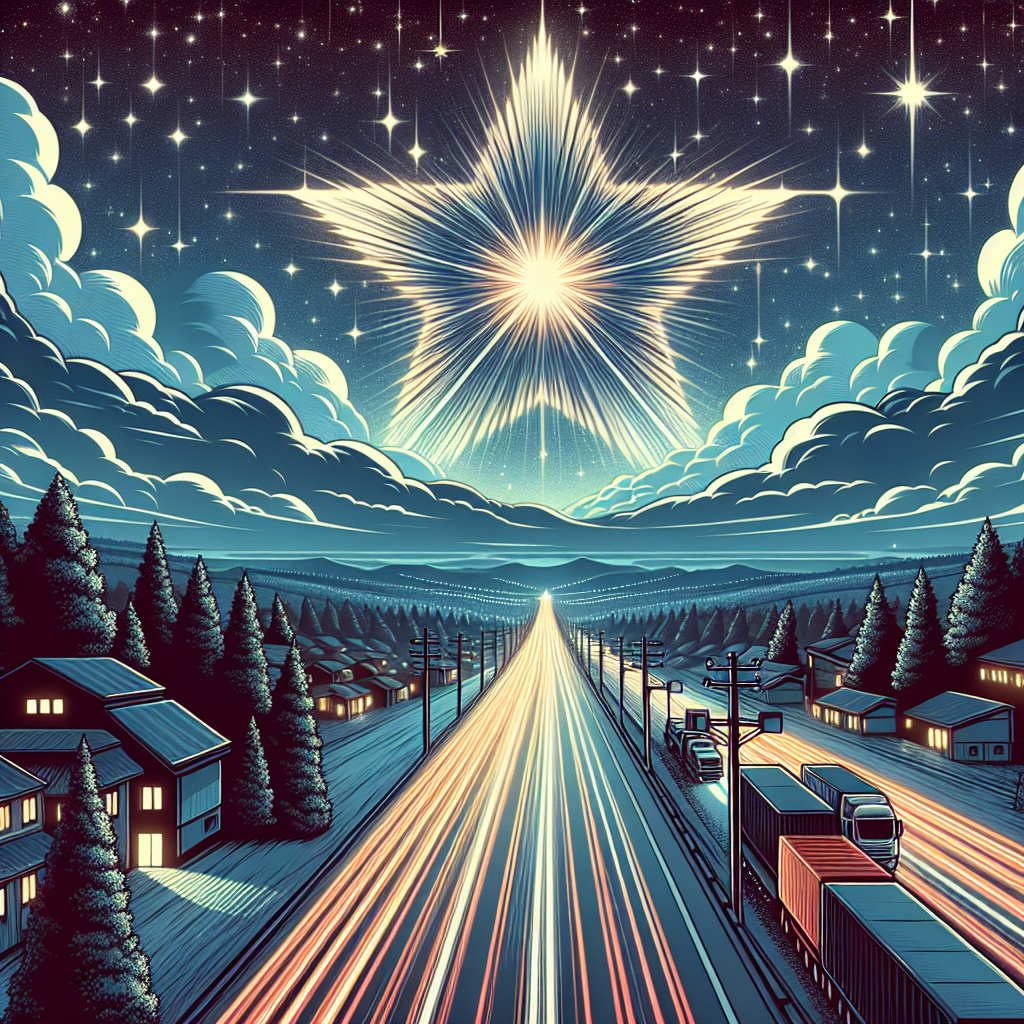

In [22]:
from langchain_openai import ChatOpenAI
from langchain_core.runnables import RunnableMap, RunnableLambda
import openai
import requests
from IPython.display import display, Image
from io import BytesIO

# API 키 설정
openai.api_key = "YOUR_API_KEY"
llm = ChatOpenAI(model="gpt-4")

# 🔹 1단계: GPT로 설명 + 키워드 추출
def extract_keyword_and_explain(question: str) -> dict:
    prompt = f"""
    사용자 질문: "{question}"
    
    아래 형식으로 응답해:
    설명: (질문에 대한 설명)
    키워드: (이미지 생성에 사용할 한 단어, 예: 사과, 자동차 등)
    """
    response = llm.invoke(prompt)
    lines = response.content.strip().split('\n')
    설명 = next((line.split(":",1)[1].strip() for line in lines if line.startswith("설명:")), "")
    키워드 = next((line.split(":",1)[1].strip() for line in lines if line.startswith("키워드:")), "")
    return {"description": 설명, "keyword": 키워드}

# 🔹 2단계: 이미지 생성
def generate_image_url(inputs: dict) -> dict:
    keyword = inputs['keyword']
    response = client.images.generate(
        model="dall-e-3",
        prompt=f"Realistic photo of {keyword} and Draw a picture in Japanese cartoon style",
        n=1,
        size="1024x1024",
        quality="standard"
    )
    image_url = response.data[0].url
    return {
        "description": inputs["description"],
        "image_url": image_url
    }

# 🔹 3단계: 이미지 출력
def display_result(result: dict):
    print("💬 설명:\n", result["description"])
    
    response_img = requests.get(result["image_url"])
    
    img = Image(data=response_img.content)  # <- 여기 수정됨!
    display(img)


full_chain = RunnableLambda(extract_keyword_and_explain) | RunnableLambda(generate_image_url)

question = "별이 빛나는 밤에"
output = full_chain.invoke(question)
display_result(output)


In [ ]:
# 스트리밍 예제 : 문장을 한글자씩 받아 출력
import time
message = [
    {"role":"system", "content":"대한민국을 사랑하는 도우미야. 도시 이름 한글자씩 출력하는 도우미입니다. 다른 문장은 출력금지입니다."},
    {"role":"user","content":"아시아 국가들의 수도를 5개 알려줘. 도시이름만 출력해줘"}
]
cli